##Lotka Volterra with logistic growth


\begin{equation*}
    \frac{dC}{dt}= r_c \cdot C - \alpha \cdot C\cdot D - \beta \cdot C \cdot P - \eta \cdot C ^2
\end{equation*}
\begin{equation*}
    \frac{dD}{dt}= \alpha C\cdot D - \nu \cdot D
\end{equation*}
\begin{equation*}
    \frac{dP}{dt}= r_P \cdot P - \eta P \cdot C - \gamma \cdot P^2
\end{equation*}
$r_c, r_p =$  natural growth rate of public and private in Monoculture.
Effect of P on C population = $\beta$,  Benefit shearing( Public to Cheater) = $\alpha$,  Effect of C on Q  Population =$\eta$, and mortality rate of cheater Population  = $\nu$, related to the carrying capacity of Public Population  = $\eta$, related to the carrying capacity of Private Population  = $\gamma$.

Equilibrium Point: [  90.16821251   89.86606102 1058.81658868]
Eigenvalues: [0.04879178+0.08038411j 0.04879178-0.08038411j 0.02783721+0.j        ]
Unstable equilibrium.


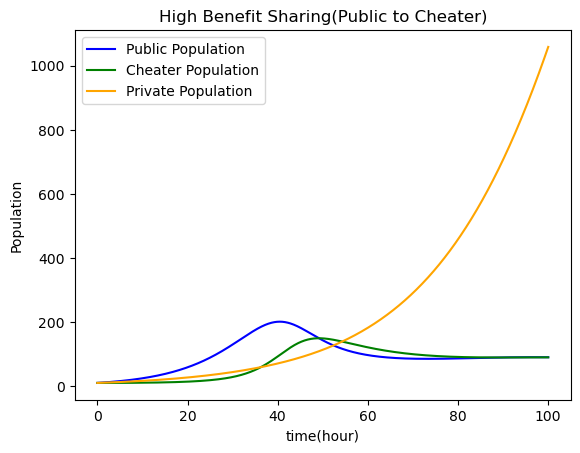

In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.001  # benefit from cooperator to defector
mu = .1 # growth rate (benefit) of cooperator
eta = .05  # growth rate (benefit) of private
nu = 0.001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 10.0, 10.0, 10.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 100, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plotgame(t, C, D, P)
plt.title('High Benefit Sharing(Public to Cheater)')
plt.show()


In [20]:
import numpy as np
from scipy.optimize import fsolve
from scipy.linalg import eigvals

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C
    dDdt = -nu * D * D + alpha * C * D
    dPdt = eta * P - beta * C * P - gamma * P * P
    return dCdt, dDdt, dPdt

def find_equilibrium(nu, beta, alpha, mu, gamma, eta):
    # Function to find equilibrium point by setting derivatives to zero
    equilibrium_func = lambda y: deriv(y, 0, nu, beta, alpha, mu, gamma, eta)
    # Initial guess for the equilibrium point
    initial_guess = [0, 0, 0]
    # Use fsolve to find the root (equilibrium point)
    equilibrium_point = fsolve(equilibrium_func, initial_guess)
    return equilibrium_point

def calculate_eigenvalues(equilibrium_point, nu, beta, alpha, mu, gamma, eta):
    # Jacobian matrix at equilibrium point
    J = np.array([
        [mu - alpha * equilibrium_point[1] - 2 * beta * equilibrium_point[0], -alpha * equilibrium_point[0], -beta * equilibrium_point[0]],
        [alpha * equilibrium_point[1], -nu + alpha * equilibrium_point[0], 0],
        [-beta * equilibrium_point[2], 0, eta - beta * equilibrium_point[0] - 2 * gamma * equilibrium_point[2]]
    ])
    # Calculate eigenvalues of the Jacobian matrix
    eigenvalues = eigvals(J)
    return eigenvalues

# Input parameter values
beta = float(input("Enter the value for beta: "))
gamma = float(input("Enter the value for gamma: "))
alpha = float(input("Enter the value for alpha: "))
mu = float(input("Enter the value for mu: "))
eta = float(input("Enter the value for eta: "))
nu = float(input("Enter the value for nu: "))

# Find equilibrium point
equilibrium_point = find_equilibrium(nu, beta, alpha, mu, gamma, eta)
print("Equilibrium Point:", equilibrium_point)

# Calculate eigenvalues at equilibrium point
eigenvalues = calculate_eigenvalues(equilibrium_point, nu, beta, alpha, mu, gamma, eta)
print("Eigenvalues:", eigenvalues)


Enter the value for beta: .00001
Enter the value for gamma: .005
Enter the value for alpha: .004
Enter the value for mu: .9
Enter the value for eta: .8
Enter the value for nu: .0003
Equilibrium Point: [0. 0. 0.]
Eigenvalues: [ 9.e-01+0.j -3.e-04+0.j  8.e-01+0.j]


Equilibrium Point: [4837.33618225   55.8736897  4920.67195361]
Eigenvalues: [-0.07668977+0.j  0.03404226+0.j  0.04682862+0.j]
Unstable equilibrium.


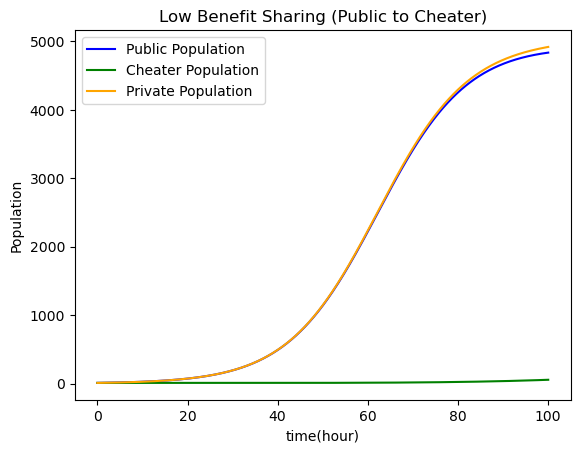

In [92]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.00001  # benefit from cooperator to defector
mu = .1 # growth rate (benefit) of cooperator
eta = .1  # growth rate (benefit) of private
nu = 0.0001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 10.0, 10.0, 10.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 100, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plotgame(t, C, D, P)
plt.title('Low Benefit Sharing (Public to Cheater)')
plt.show()


Equilibrium Point: [ 268.47252922  595.97818846 8601.33253655]
Eigenvalues: [-0.07652888+0.j          0.03179874+0.03932381j  0.03179874-0.03932381j]
Unstable equilibrium.


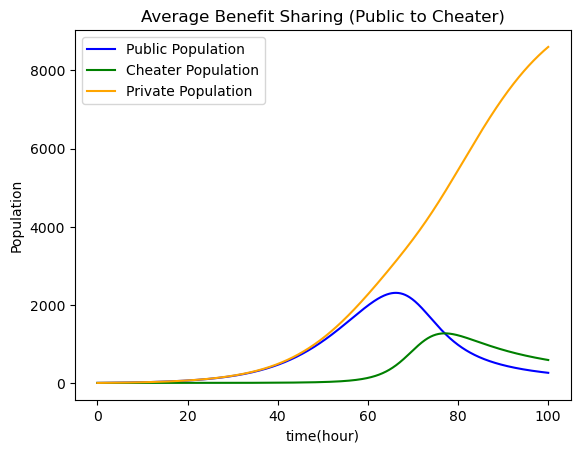

In [2]:
import numpy as np
from scipy.integrate import odeint
from scipy.linalg import eigvals
import matplotlib.pyplot as plt

def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population

    return dCdt, dDdt, dPdt

def jacobian(y, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    J = np.array([
        [mu - alpha * D - 2 * beta * C, -alpha * C, -beta * C],
        [alpha * D, -nu + alpha * C, 0],
        [-beta * P, 0, eta - beta * C - 2 * gamma * P]
    ])
    return J

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = .1 # growth rate (benefit) of cooperator
eta = .1  # growth rate (benefit) of private
nu = 0.0001  # transportation cost of defector

# Initial conditions
C0, D0, P0 = 10.0, 10.0, 10.0
y0 = C0, D0, P0

# Time grid
t = np.linspace(0, 100, 1000)

# Integrate the equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))

# Get the equilibrium point (last point of the integration)
equilibrium_point = ret[-1]

# Calculate Jacobian matrix at equilibrium point
Jacobian_matrix = jacobian(equilibrium_point, nu, beta, alpha, mu, gamma, eta)

# Calculate eigenvalues of the Jacobian matrix
eigenvalues = eigvals(Jacobian_matrix)

# Display the equilibrium point and eigenvalues
print("Equilibrium Point:", equilibrium_point)
print("Eigenvalues:", eigenvalues)

# Check stability conditions
real_parts = np.real(eigenvalues)
if all(real_parts < 0):
    print("Stable equilibrium.")
else:
    print("Unstable equilibrium.")

# Plot the results
C, D, P = ret.T
def plotgame(t, C, D, P):
    f, ax = plt.subplots()
    ax.plot(t, C, 'b', label='Public Population')
    ax.plot(t, D, 'g', label='Cheater Population')
    ax.plot(t, P, 'orange', label='Private Population')
    plt.tick_params(axis='y')
    plt.tick_params(axis='x')
    plt.xlabel('time(hour)')
    plt.ylabel('Population')
    legend = ax.legend()

plotgame(t, C, D, P)
plt.title('Average Benefit Sharing (Public to Cheater)')
plt.show()
